In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import scanpy as sc
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm

In [8]:
adata = sc.read_h5ad('/mnt/research/FishEvoDevoGeno/Hao/icepop/data/simulation_input_subset/TM_subset__score_calc.h5ad')
celltype_cnts = adata.obs['cell_type'].value_counts()

In [9]:
n_bins = 5

In [10]:
# load icepop res
files = Path('/mnt/research/FishEvoDevoGeno/Hao/icepop/results/2026-01-01__gls_causal__const_w__norm__perm-1000').glob('icepop__*.csv')
files = [str(file) for file in files]

icepop_res_df = []
for file in tqdm(files, total=len(files)):
    icepop_df = pd.read_csv(file, header=0, index_col=None)

    params_df = []
    for setting in icepop_df['setting']:
        params = {i.split('-')[0]: float(i.split('-')[1]) for i in setting.split('__')}
        params_df.append(params)
    params_df = pd.DataFrame(params_df)
    icepop_comb_df = pd.concat([params_df, icepop_df.loc[:, ['celltype', 'q', 'target', 'run_idx']]], axis=1)
    icepop_comb_df['method'] = 'icepop'
    icepop_res_df.append(icepop_comb_df)
icepop_res_df = pd.concat(icepop_res_df, axis=0, ignore_index=True)

# load seismic res
files = Path('/mnt/research/FishEvoDevoGeno/Hao/icepop/results/2026-01-11__seismic_casual').glob('*.tsv')
files = [str(file) for file in files]
params_df = []
seismic_res_df = []
for file in tqdm(files, total=len(files)):
    seismic_df = pd.read_csv(file, header=0, index_col=None, sep='\t')
    seismic_df = seismic_df.rename(columns={'cell_type': 'celltype', 'FDR': 'q'})
    
    setting = Path(file).stem
    params = {i.split('-')[0]: float(i.split('-')[1]) for i in setting.split('__')}
    seismic_df['run_idx'] = int(params['run'])
    del params['run']
    params_df.extend([params] * len(seismic_df))

    aset = setting.split("__run-")[0]
    run = setting.split("__run-")[1]
    with open(f'/mnt/research/FishEvoDevoGeno/Hao/icepop/data/causal_simulation_subset_data__celltype__logfc/{aset}/tc__{run}.csv', 'r') as f:
        target = f.read().strip()
    seismic_df['target'] = seismic_df['celltype'] == target
    
    seismic_res_df.append(seismic_df.loc[:, ['celltype', 'q', 'target', 'run_idx']])
seismic_comb_df = pd.concat(
    [
        pd.DataFrame(params_df),
        pd.concat(seismic_res_df, ignore_index=True)
    ],
    axis=1
)
seismic_comb_df['method'] = 'seismic'

# load scdrs
files = Path('/mnt/research/FishEvoDevoGeno/Hao/icepop/results/2026-01-11__scdrs_casual').rglob('*.cell_type')
files = [str(file) for file in files]
params_df = []
scdrs_res_df = []
for file in tqdm(files, total=len(files)):
    scdrs_df = pd.read_csv(file, header=0, index_col=None, sep='\t')
    scdrs_df['q'] = multipletests(scdrs_df['assoc_mcp'], method='fdr_bh')[1]
    scdrs_df = scdrs_df.rename(columns={'group': 'celltype'})
    
    setting = Path(file).parent.name
    run = int(Path(file).name.split('.scdrs_group')[0].split('__')[1])
    params = {i.split('-')[0]: float(i.split('-')[1]) for i in setting.split('__')}
    scdrs_df['run_idx'] = run
    params_df.extend([params] * len(scdrs_df))

    with open(f'/mnt/research/FishEvoDevoGeno/Hao/icepop/data/causal_simulation_subset_data__celltype__logfc/{setting}/tc__{run}.csv', 'r') as f:
        target = f.read().strip()
    scdrs_df['target'] = scdrs_df['celltype'] == target
    
    scdrs_res_df.append(scdrs_df.loc[:, ['celltype', 'q', 'target', 'run_idx']])
scdrs_comb_df = pd.concat(
    [
        pd.DataFrame(params_df),
        pd.concat(scdrs_res_df, ignore_index=True)
    ],
    axis=1
)
scdrs_comb_df['method'] = 'scdrs'

res_df = pd.concat([icepop_res_df, seismic_comb_df, scdrs_comb_df], axis=0, ignore_index=True)
res_df = res_df[res_df['target']]
res_df['discovery'] = res_df['q'] <= 0.1

# keep cnts in res only
celltype_cnts = celltype_cnts[celltype_cnts.index.isin(res_df['celltype'])]
bins = pd.qcut(celltype_cnts, q=n_bins, labels=[f"bin_{i+1}" for i in range(n_bins)])

res_df['celltype_cnts'] = list(celltype_cnts.loc[res_df['celltype']])
res_df['bins'] = list(bins.loc[res_df['celltype']])

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/1700 [00:00<?, ?it/s]

  0%|          | 0/1700 [00:00<?, ?it/s]

In [11]:
NOISE_SD_FIXED = 1.0
BETA_FIXED = 1.0
FRAC_SIGNAL_FIXED = 0.01
SAMPLE_RATE_FIXED = 1.0

# experiment A: vary signal strength
FRAC_SIGNAL_LIST = [0.001, 0.005, 0.01, 0.05, 0.1]

# experiment B: vary noise_sd
NOISE_SD_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment C: vary beta
BETA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment D: vary cell sampling rate
SAMPLE_RATE_LIST = [0.2, 0.4, 0.6, 0.8, 1.0]

# experiment A: vary signal strength

In [12]:
def prepare_plot(res_df, vlabel='sf', bins=None):
    if vlabel == 'sf':
        a_df = res_df[
            (res_df['sf'].isin(FRAC_SIGNAL_LIST)) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'ns':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'].isin(NOISE_SD_LIST)) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'b':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'].isin(BETA_LIST)) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'sr':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'].isin(SAMPLE_RATE_LIST))
        ]
    if bins:
        a_df = a_df[a_df['bins'] == bins]
    icepop_ares = a_df[a_df['method'] == 'icepop']
    seismic_ares = a_df[a_df['method'] == 'seismic']
    scdrs_ares = a_df[a_df['method'] == 'scdrs']
    icepop_ares = (
        icepop_ares.groupby(vlabel)["discovery"]
          .mean()
          .rename("power")
    )
    seismic_ares = (
        seismic_ares.groupby(vlabel)["discovery"]
          .mean()
          .rename("power")
    )
    scdrs_ares = (
        scdrs_ares.groupby(vlabel)["discovery"]
          .mean()
          .rename("power")
    )
    icepop_ares = pd.DataFrame(icepop_ares).reset_index()
    seismic_ares = pd.DataFrame(seismic_ares).reset_index()
    scdrs_ares = pd.DataFrame(scdrs_ares).reset_index()
    icepop_ares['method'] = 'icepop'
    seismic_ares['method'] = 'seismic'
    scdrs_ares['method'] = 'scdrs'
    df = pd.concat([icepop_ares, seismic_ares, scdrs_ares], axis=0, ignore_index=True)
    return df

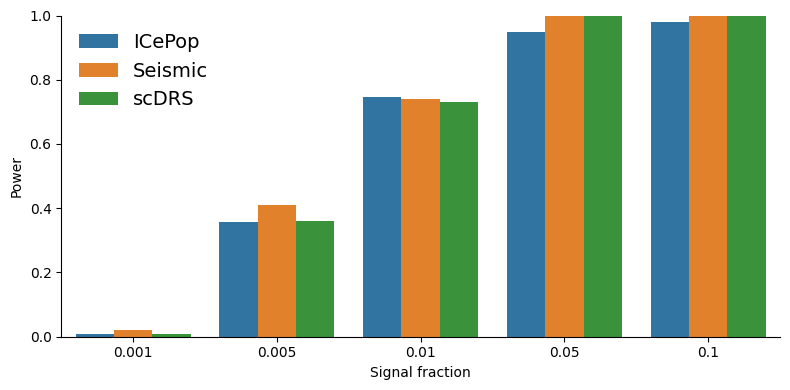

In [15]:
vlabel = 'sf'
df = prepare_plot(res_df, vlabel=vlabel)

plt.figure(figsize=(8,4))
ax = sns.barplot(
    data=df,
    x=vlabel,
    y="power",
    hue="method",
)

plt.xlabel('Signal fraction')
plt.ylabel("Power")
plt.ylim(0.0, 1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---- Rename legend entries ----
new_labels = ["ICePop", "Seismic", "scDRS"]  # order must match plotting order

handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    new_labels,
    frameon=False,      # remove legend frame
    fontsize=14
)

plt.tight_layout()
plt.savefig('../paper/schematics/legend.pdf')